

# Topic Modeling (1)
### OPIM 5512 — Applied Data Science · Module5

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5512-notebooks/blob/main/Module5/TopicModeling (1).ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Document Embeddings and Topic Modeling with KMeans Clustering
----------------------
**Dr. Dave Wanik - Operations and Information Management - University of Connecticut**

This is a real-world method that has brought me value of the past few years and I'm excited to share it with you... with some enchancements! You can use PCA or UMAP for visualization of document embeddings. If you want to make it fancy(ier), use DBSCAN and UMAP instead of PCA and KMeans.

In [ ]:
!pip install datasets sentence-transformers scikit-learn transformers[torch] --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 11.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.1.2
    Uninstalling sentence-transformers-5.1.2:
      Successfully uninstalled sen

# 🤗 Setup & Load BillSum

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np

# ------------------------------------------------
# Load BillSum (you can swap this for your own copy)
# ------------------------------------------------
dataset = load_dataset("billsum", "default")  # "us" split

# Convert to DataFrame for convenience
df = dataset["train"].to_pandas()

# Peek
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/91.8M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

data/ca_test-00000-of-00001.parquet:   0%|          | 0.00/6.12M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18949 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3269 [00:00<?, ? examples/s]

Generating ca_test split:   0%|          | 0/1237 [00:00<?, ? examples/s]

,text,summary,title
0,SECTION 1. LIABILITY OF BUSINESS ENTITIES PROV...,Shields a business entity from civil liability...,A bill to limit the civil liability of busines...
1,SECTION 1. SHORT TITLE.\n\n This Act may be...,Human Rights Information Act - Requires certai...,Human Rights Information Act
2,SECTION 1. SHORT TITLE.\n\n This Act may be...,Jackie Robinson Commemorative Coin Act - Direc...,Jackie Robinson Commemorative Coin Act
3,SECTION 1. NONRECOGNITION OF GAIN WHERE ROLLOV...,Amends the Internal Revenue Code to provide (t...,To amend the Internal Revenue Code to provide ...
4,SECTION 1. SHORT TITLE.\n\n This Act may be...,Native American Energy Act - (Sec. 3) Amends t...,Native American Energy Act


In [ ]:
df['text'][0]

"SECTION 1. LIABILITY OF BUSINESS ENTITIES PROVIDING USE OF FACILITIES \n              TO NONPROFIT ORGANIZATIONS.\n\n    (a) Definitions.--In this section:\n            (1) Business entity.--The term ``business entity'' means a \n        firm, corporation, association, partnership, consortium, joint \n        venture, or other form of enterprise.\n            (2) Facility.--The term ``facility'' means any real \n        property, including any building, improvement, or appurtenance.\n            (3) Gross negligence.--The term ``gross negligence'' means \n        voluntary and conscious conduct by a person with knowledge (at \n        the time of the conduct) that the conduct is likely to be \n        harmful to the health or well-being of another person.\n            (4) Intentional misconduct.--The term ``intentional \n        misconduct'' means conduct by a person with knowledge (at the \n        time of the conduct) that the conduct is harmful to the health \n        or well-being

In [ ]:
# Use the full bill text for modeling/search
df["doc_text"] = df["text"].fillna("")  # or use summary if you prefer

# To keep things light on a laptop:
N_DOCS = 2000   # adjust up/down depending on your machine
df_small = df.sample(n=N_DOCS, random_state=42).reset_index(drop=True)


# 🔵 Topic Modeling (Embeddings + KMeans)

We’ll use `SentenceTransformers` + `KMeans` to get topics.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# ----------------------------------------
# 1. Encode documents
# ----------------------------------------
embed_model = SentenceTransformer("all-MiniLM-L6-v2")  # small, fast

docs = df_small["doc_text"].tolist()
embeddings = embed_model.encode(docs, batch_size=32, show_progress_bar=True)

# ----------------------------------------
# 2. Cluster embeddings into topics
# ----------------------------------------
N_TOPICS = 5   # tweak based on how granular you want
kmeans = KMeans(n_clusters=N_TOPICS, random_state=42, n_init="auto")
topic_labels = kmeans.fit_predict(embeddings)

df_small["topic_id"] = topic_labels


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

### Quick inspection of topics:

In [ ]:
# Show 3 example documents per topic
for t in range(N_TOPICS):
    print(f"\n===== TOPIC {t} =====")
    examples = df_small[df_small["topic_id"] == t].head(3)
    for i, row in examples.iterrows():
        print(f"\nTitle: {row.get('title', '')}")
        print(f"Summary: {row.get('summary', '')[:300]}...")



===== TOPIC 0 =====

Title: Local Zoning and Property Rights Protection Act of 2015
Summary: Local Zoning and Property Rights Protection Act of 2015 This bill requires the Secretary of Housing and Urban Development (HUD) to withdraw:   the proposed HUD rule entitled &quot;Affirmatively Furthering Fair Housing (AFFH),&quot; any final rule based on it (including the rule with the Regulation I...

Title: A bill to establish the Paterson Great Falls National Historical Park, and for other purposes.
Summary: Paterson Great Falls National Historical Park Act - Establishes the Paterson Great Falls National Historical Park in New Jersey as a unit of the National Park System.

Sets forth conditions concerning the establishment of the Park.

 Sets forth provisions regarding the administration of the Park.

 ...

Title: To amend the Federal Water Pollution Control Act to authorize appropriations for State water pollution control revolving funds, and for other purposes.
Summary: Clean Water Infra

## Auto-label the names

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def get_topic_labels(df, text_col="doc_text", topic_col="topic_id", top_n=5):
    topic_labels = {}
    vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)

    for t in sorted(df[topic_col].unique()):
        # Get docs for this topic
        docs_t = df[df[topic_col] == t][text_col].tolist()

        # Fit TF-IDF just on these documents
        X = vectorizer.fit_transform(docs_t)
        feature_names = vectorizer.get_feature_names_out()

        # Compute mean TF-IDF score for each term in this cluster
        mean_tfidf = X.mean(axis=0).A1
        top_indices = mean_tfidf.argsort()[::-1][:top_n]

        # Build topic name
        top_words = [feature_names[i] for i in top_indices]
        topic_labels[t] = " ".join(top_words)

    return topic_labels

# Generate the topic names
labels = get_topic_labels(df_small, text_col="doc_text")
labels


{np.int32(0): 'shall secretary act land section',
 np.int32(1): 'shall act section secretary states',
 np.int32(2): 'shall section act states united',
 np.int32(3): 'section shall act secretary health',
 np.int32(4): 'section shall year act taxable'}

# Need some stop words for clarity!
Did you see the words above have some 'junk'? Boring words like 'shall', 'act' and 'section'? Let's add some stop words and THEN do the clustering again.

In [ ]:
# ---------------------------------------------------------
# 1. Custom stopwords (general + legal boilerplate)
# ---------------------------------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

legal_stopwords = {
    "shall", "section", "act", "secretary", "states", "united",
    "year", "subsection", "federal", "state", "agency", "program",
    "title", "paragraph", "purpose", "include", "includes", "including",
    "require", "requires", "required", "thereof", "herein"
}

# Convert the frozenset to a list for TfidfVectorizer
custom_stopwords = list(ENGLISH_STOP_WORDS.union(legal_stopwords))

# ---------------------------------------------------------
# 2. Function to auto-label each topic
# ---------------------------------------------------------
def get_topic_labels(df, text_col="doc_text", topic_col="topic_id",
                     top_n=5, max_features=5000):
    """
    For each topic_id in df[topic_col], compute a TF-IDF model
    on the documents in that topic and return a dict:
        {topic_id: "nice topic name"}
    """
    topic_labels = {}

    for t in sorted(df[topic_col].unique()):
        docs_t = df[df[topic_col] == t][text_col].tolist()
        if len(docs_t) == 0:
            topic_labels[t] = "unknown"
            continue

        # TF-IDF just within this topic cluster
        vectorizer = TfidfVectorizer(
            stop_words=custom_stopwords,
            max_features=max_features,
            ngram_range=(1, 2),                 # unigrams + bigrams
            token_pattern=r"(?u)\b[A-Za-z][A-Za-z]+\b"  # no single letters / pure numbers
        )

        X = vectorizer.fit_transform(docs_t)
        feature_names = vectorizer.get_feature_names_out()

        # Mean TF-IDF score per term in this cluster
        mean_tfidf = X.mean(axis=0).A1
        top_indices = mean_tfidf.argsort()[::-1][:top_n]

        top_words = [feature_names[i] for i in top_indices]
        topic_labels[t] = " ".join(top_words)

    return topic_labels

# ---------------------------------------------------------
# 3. Generate labels + attach them back to df_small
# ---------------------------------------------------------
topic_name_map = get_topic_labels(df_small, text_col="doc_text", topic_col="topic_id", top_n=5)

print("AUTO-GENERATED TOPIC NAMES:\n")
for t, name in topic_name_map.items():
    print(f"Topic {t:2d}: {name}")

# Optional: add a human-readable name column to your df
df_small["topic_name"] = df_small["topic_id"].map(topic_name_map)

print('#############')
print('First few rows:')
# Peek
df_small[["title", "topic_id", "topic_name"]].head(10)

AUTO-GENERATED TOPIC NAMES:

Topic  0: land national water lands management
Topic  1: health commission sec school care
Topic  2: commission information inserting sec person
Topic  3: health services striking veterans inserting
Topic  4: taxable qualified credit code amended
#############
First few rows:


,title,topic_id,topic_name
0,Medicare Prescription Drug Integrity Act of 2013,3,health services striking veterans inserting
1,A bill to amend the Internal Revenue Code of 1...,4,taxable qualified credit code amended
2,"To amend the Federal Food, Drug, and Cosmetic ...",3,health services striking veterans inserting
3,Local Zoning and Property Rights Protection Ac...,0,land national water lands management
4,A bill to establish the Paterson Great Falls N...,0,land national water lands management
5,Honesty in Sweepstakes Act of 1999,2,commission information inserting sec person
6,"Recognize, Assist, Include, Support, and Engag...",3,health services striking veterans inserting
7,To amend the Federal Water Pollution Control A...,0,land national water lands management
8,Leveraging Performance-Based Transportation Se...,2,commission information inserting sec person
9,To authorize the Secretary of Housing and Urba...,4,taxable qualified credit code amended


# 🔵 Visualization

### Simple Bar Plot
Shows the frequency of each topic.

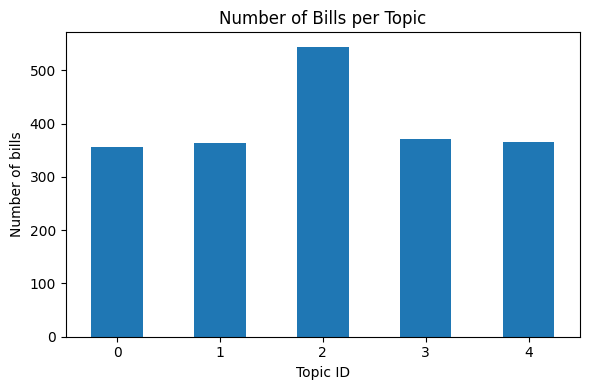

In [ ]:
import matplotlib.pyplot as plt

topic_counts = df_small["topic_id"].value_counts().sort_index()

plt.figure(figsize=(6,4))
topic_counts.plot(kind="bar")
plt.xlabel("Topic ID")
plt.ylabel("Number of bills")
plt.title("Number of Bills per Topic")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Figure 1:** Frequncy of bills by topic ID (bar plot)

## 1D space - what did your transformer learn? 1x384.
Let's look at the embeddings of 10 random rows!

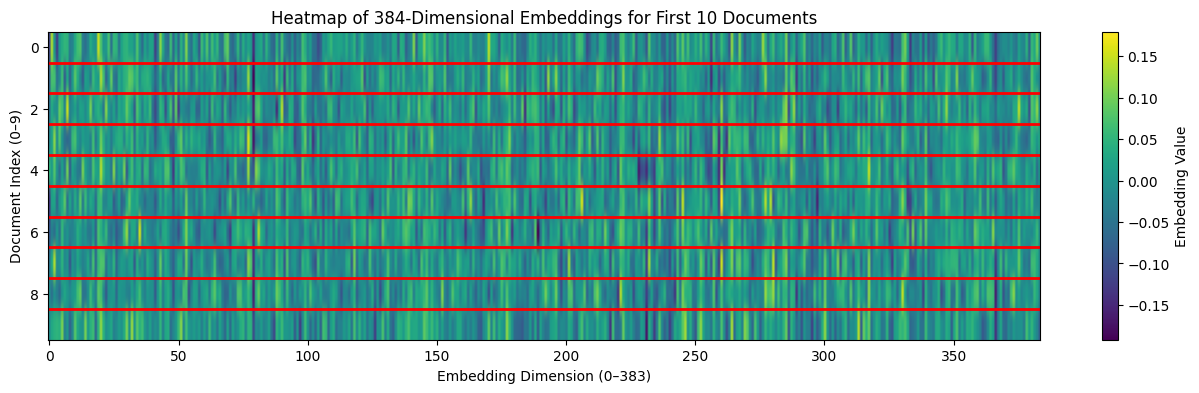

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Take the first 10 embeddings
emb_subset = np.array(embeddings[:10])

plt.figure(figsize=(16, 4))
plt.imshow(emb_subset, aspect="auto", cmap="viridis")

# Add horizontal separator lines every 1 unit (between rows)
for i in range(1, 10):  # separators between the 10 rows
    plt.axhline(i - 0.5, color="red", linewidth=2)

plt.colorbar(label="Embedding Value")
plt.xlabel("Embedding Dimension (0–383)")
plt.ylabel("Document Index (0–9)")
plt.title("Heatmap of 384-Dimensional Embeddings for First 10 Documents")

plt.show()


**Figure 2:** color-coded 384 dimensions that were calcualted for each document (n=10)

## All of them per cluster!

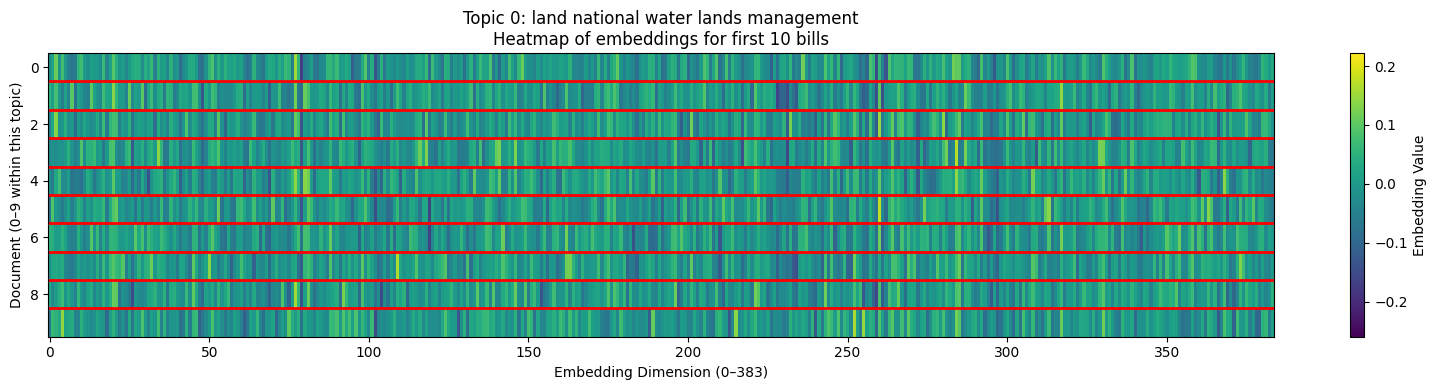

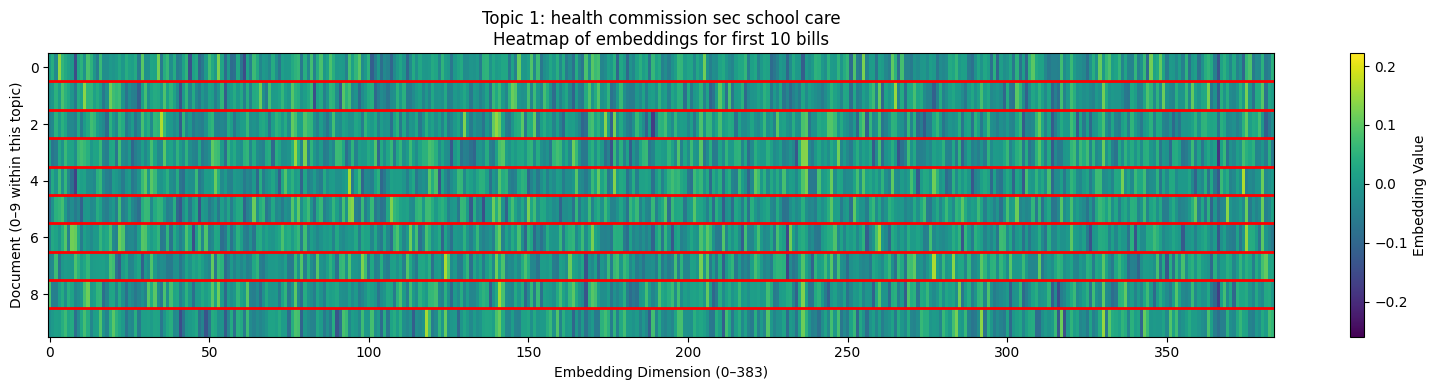

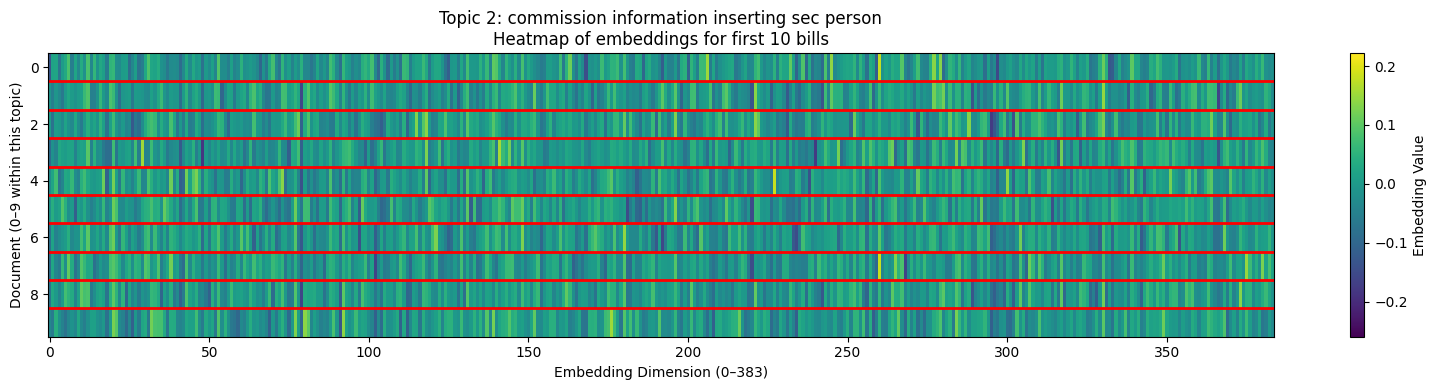

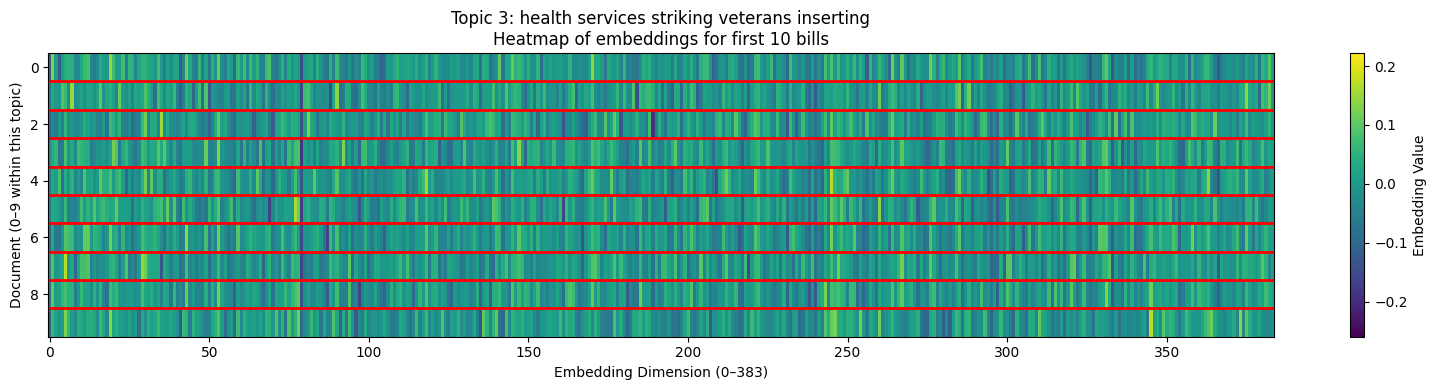

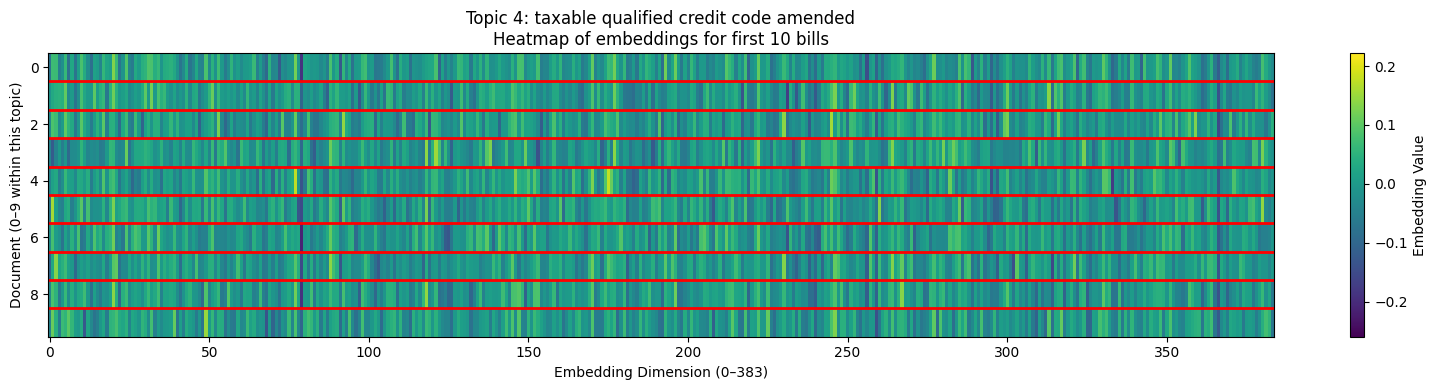

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure embeddings is a NumPy array
embeddings_arr = np.array(embeddings)

# For consistent colors across all topics
global_vmin = embeddings_arr.min()
global_vmax = embeddings_arr.max()

unique_topics = sorted(df_small["topic_id"].unique())

for t in unique_topics:
    # indices of docs in this topic
    idx = df_small.index[df_small["topic_id"] == t][:10]   # first 10
    if len(idx) == 0:
        continue

    emb_subset = embeddings_arr[idx]

    plt.figure(figsize=(16, 4))

    # Heatmap
    plt.imshow(
        emb_subset,
        aspect="auto",
        cmap="viridis",
        vmin=global_vmin,
        vmax=global_vmax
    )

    # ---- Add horizontal red separator lines ----
    n_rows = emb_subset.shape[0]
    for i in range(1, n_rows):
        plt.axhline(i - 0.5, color="red", linewidth=2)

    plt.colorbar(label="Embedding Value")
    plt.xlabel("Embedding Dimension (0–383)")
    plt.ylabel("Document (0–9 within this topic)")

    topic_name = topic_name_map.get(t, f"Topic {t}")
    plt.title(f"Topic {t}: {topic_name}\nHeatmap of embeddings for first {n_rows} bills")

    plt.tight_layout()
    plt.show()


**Figure 3:** color-coded 384 dimensions that were calcualted for each document (n=10) for all topics.

### 2D space!

In [ ]:
!pip install umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


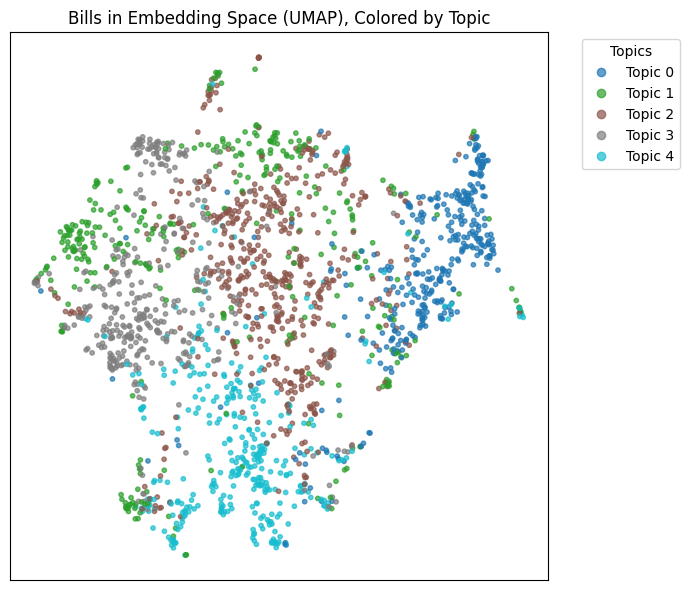

In [ ]:
import umap
import numpy as np
import matplotlib.pyplot as plt

# embeddings is shape (N, 384) from SentenceTransformer
reducer = umap.UMAP(random_state=42)
emb_2d = reducer.fit_transform(embeddings)   # shape (N, 2)

df_small["x"] = emb_2d[:, 0]
df_small["y"] = emb_2d[:, 1]

plt.figure(figsize=(7,6))
scatter = plt.scatter(
    df_small["x"],
    df_small["y"],
    c=df_small["topic_id"],
    s=10,
    alpha=0.7,
    cmap="tab10"
)

plt.title("Bills in Embedding Space (UMAP), Colored by Topic")
plt.xticks([])
plt.yticks([])

# Legend: one handle per topic
handles, _ = scatter.legend_elements(prop="colors")
labels = [f"Topic {t}" for t in sorted(df_small["topic_id"].unique())]
plt.legend(handles, labels, title="Topics", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Figure 4:** color-coded by clusters, 2 dimensions calculated and plotted. Kind of looks like Germany...

In [ ]:
topic_ref = (
    df_small[["topic_id", "topic_name"]]
    .drop_duplicates()
    .sort_values("topic_id")
    .reset_index(drop=True)
)
topic_ref


,topic_id,topic_name
0,0,land national water lands management
1,1,health commission sec school care
2,2,commission information inserting sec person
3,3,health services striking veterans inserting
4,4,taxable qualified credit code amended


# UMAP vs. PCA
UMAP is the preferred method for visualizing embeddings.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


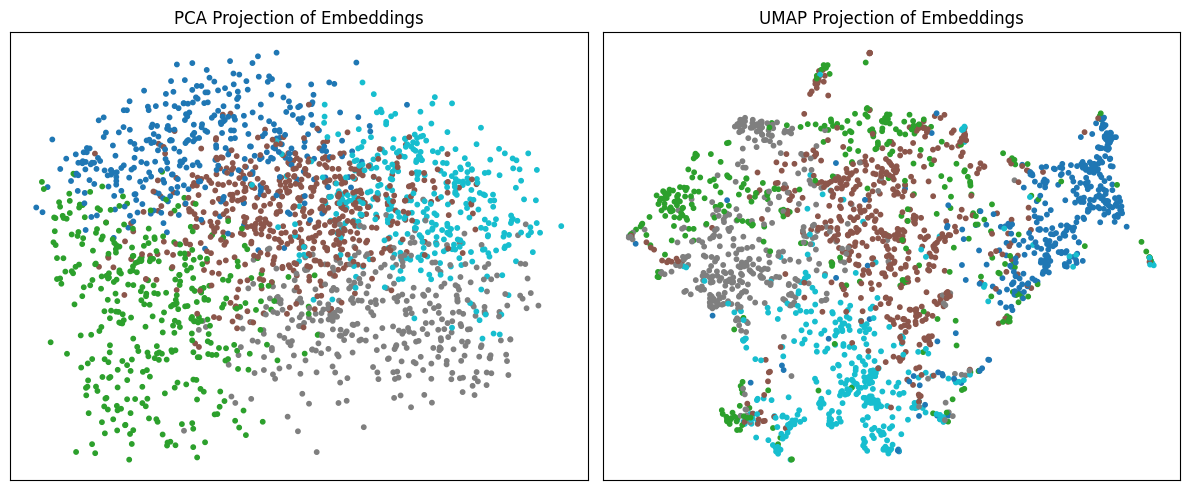

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap

# PCA
pca = PCA(n_components=2)
pca_2d = pca.fit_transform(embeddings)

# UMAP
reducer = umap.UMAP(random_state=42)
umap_2d = reducer.fit_transform(embeddings)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].scatter(pca_2d[:,0], pca_2d[:,1], c=df_small["topic_id"], cmap="tab10", s=10)
ax[0].set_title("PCA Projection of Embeddings")
ax[0].set_xticks([])
ax[0].set_yticks([])

ax[1].scatter(umap_2d[:,0], umap_2d[:,1], c=df_small["topic_id"], cmap="tab10", s=10)
ax[1].set_title("UMAP Projection of Embeddings")
ax[1].set_xticks([])
ax[1].set_yticks([])

plt.tight_layout()
plt.show()


**Figure 5:** comparison of PCA (left) vs. UMAP (right)

Doesn't UMAP look a little more compact?

## 1D space for the 2D projections... a little simpler!
The 'fingerprints' of each row!

In [ ]:
# from earlier
embeddings        # (n_docs, 384)
df_small["topic_id"]

# 2D projections
from sklearn.decomposition import PCA
import umap, numpy as np

pca = PCA(n_components=2)
pca_2d  = pca.fit_transform(embeddings)      # shape (n_docs, 2)

reducer = umap.UMAP(random_state=42)
umap_2d = reducer.fit_transform(embeddings)  # shape (n_docs, 2)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


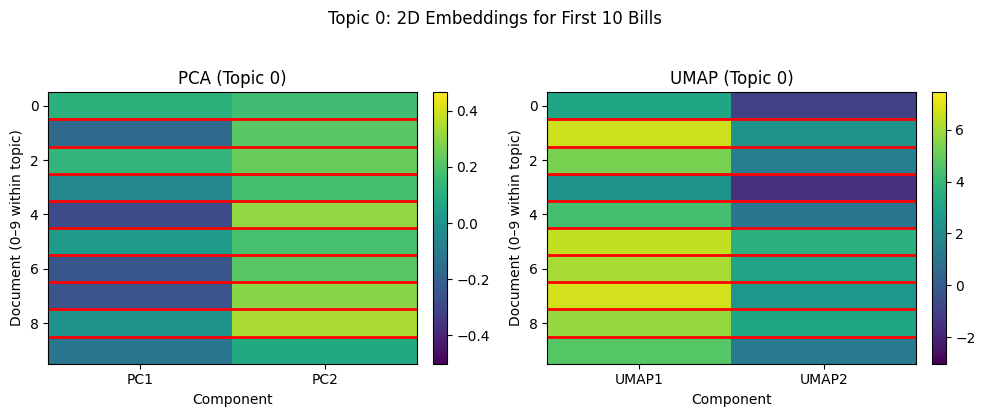

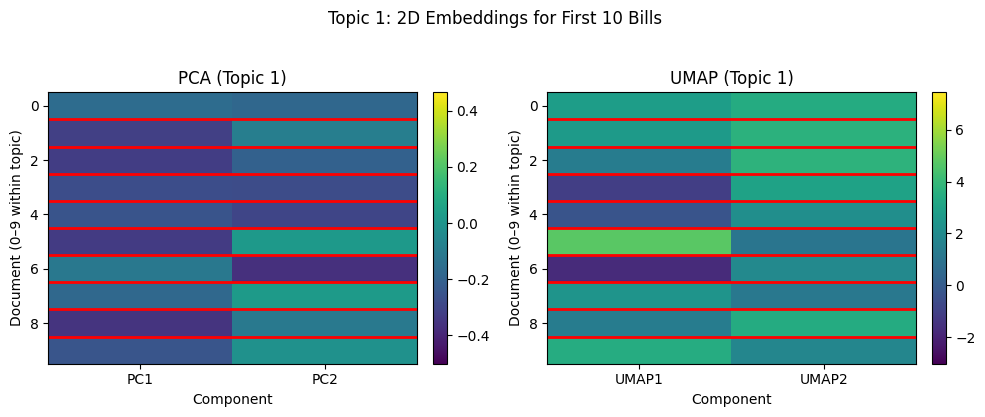

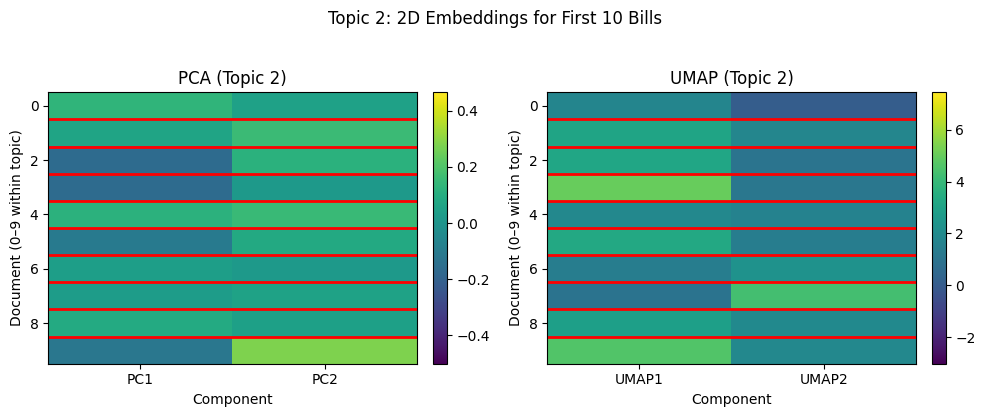

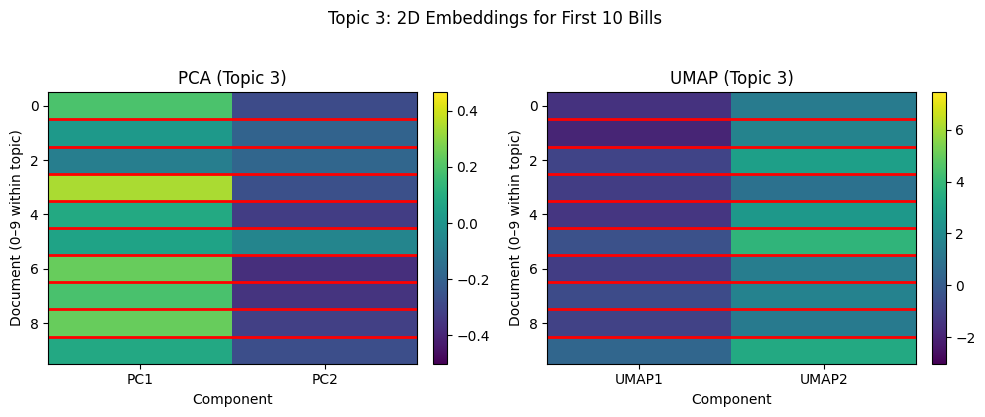

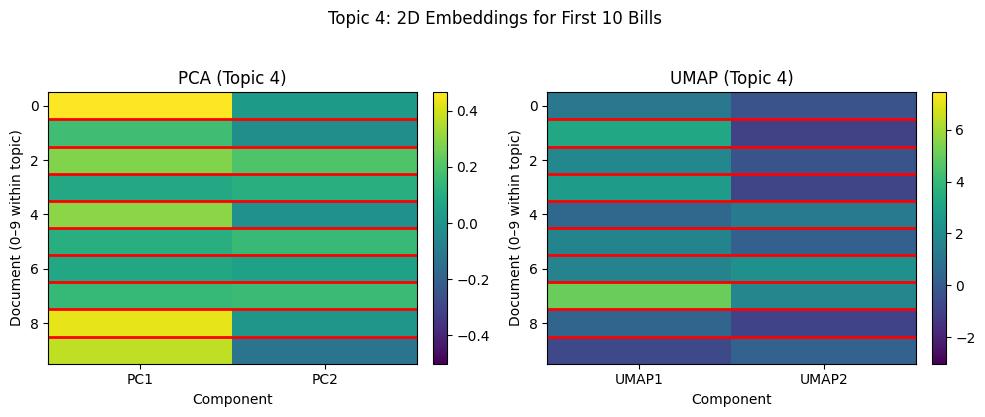

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

pca_arr  = np.array(pca_2d)
umap_arr = np.array(umap_2d)

unique_topics = sorted(df_small["topic_id"].unique())

# For consistent color scale across topics
pca_vmin,  pca_vmax  = pca_arr.min(),  pca_arr.max()
umap_vmin, umap_vmax = umap_arr.min(), umap_arr.max()

for t in unique_topics:
    idx = df_small.index[df_small["topic_id"] == t][:10]  # up to 10 docs in this topic
    if len(idx) == 0:
        continue

    pca_subset  = pca_arr[idx]    # (<=10, 2)
    umap_subset = umap_arr[idx]   # (<=10, 2)
    n_rows      = len(idx)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # ==========================
    # ----- PCA heatmap -----
    # ==========================
    im1 = axes[0].imshow(
        pca_subset,
        aspect="auto",
        cmap="viridis",
        vmin=pca_vmin,
        vmax=pca_vmax
    )
    axes[0].set_title(f"PCA (Topic {t})")
    axes[0].set_xlabel("Component")
    axes[0].set_ylabel("Document (0–9 within topic)")
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(["PC1", "PC2"])

    # 🔥 Add red separator lines
    for i in range(1, n_rows):
        axes[0].axhline(i - 0.5, color="red", linewidth=2)

    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # ==========================
    # ----- UMAP heatmap -----
    # ==========================
    im2 = axes[1].imshow(
        umap_subset,
        aspect="auto",
        cmap="viridis",
        vmin=umap_vmin,
        vmax=umap_vmax
    )
    axes[1].set_title(f"UMAP (Topic {t})")
    axes[1].set_xlabel("Component")
    axes[1].set_ylabel("Document (0–9 within topic)")
    axes[1].set_xticks([0, 1])
    axes[1].set_xticklabels(["UMAP1", "UMAP2"])

    # 🔥 Add red separator lines
    for i in range(1, n_rows):
        axes[1].axhline(i - 0.5, color="red", linewidth=2)

    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    plt.suptitle(f"Topic {t}: 2D Embeddings for First {n_rows} Bills", y=1.03, fontsize=12)
    plt.tight_layout()
    plt.show()


**Figure 6:** comparison of PCA (left) vs. UMAP (right) for first 10 records. Note how they of course kinda look similar!

* Each row = one bill in that topic
* Columns = the two coordinates in PCA space (left) or UMAP space (right)
* Color = magnitude of the coordinate

Within a topic, some bills have very similar 2D coordinates, hence, they sit close together on the scatterplot!

# In practice...
Don't forget to use `fit_transform` on training data and `transform` on new, unseen test data!

# 🤗 (optional) Named Entity Recognition
We can pull out the names of organizations and locations or other miscellaneous. Needs some tuning but a nice hands-off way of getting more info from a corpus!

Label	Meaning	Examples
* `PER`	Person	John Smith, Senator Jones
* `ORG`	Organization	U.S. Congress, Department of Agriculture, Big Sky Lumber Co.
* `LOC`	Location	Montana, Gallatin National Forest
* `MISC`	Miscellaneous named entities	Acts, events, nationalities, laws, products

In [ ]:
from datasets import load_dataset
from transformers import pipeline

# -------------------------
# Load a few BillSum samples
# -------------------------
dataset = load_dataset("billsum", "default")
df = dataset["train"].to_pandas()

# Let's take one bill summary (shorter & good for NER demos)
text = df["summary"].iloc[0]
print("BILL SUMMARY:\n", text)

# -------------------------
# Build an NER pipeline
# -------------------------
ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"   # groups subwords
)

# -------------------------
# Run NER
# -------------------------
entities = ner(text)

print("\nEXTRACTED ENTITIES:")
for ent in entities:
    print(f"{ent['word']:25}  {ent['entity_group']:10}  score={ent['score']:.2f}")

BILL SUMMARY:
 Shields a business entity from civil liability relating to any injury or death occurring at a facility of that entity in connection with a use of such facility by a nonprofit organization if: (1) the use occurs outside the scope of business of the business entity; (2) such injury or death occurs during a period that such facility is used by such organization; and (3) the business entity authorized the use of such facility by the organization. 
Makes this Act inapplicable to an injury or death that results from an act or omission of a business entity that constitutes gross negligence or intentional misconduct, including misconduct that: (1) constitutes a hate crime or a crime of violence or act of international terrorism for which the defendant has been convicted in any court; or (2) involves a sexual offense for which the defendant has been convicted in any court or misconduct for which the defendant has been found to have violated a Federal or State civil rights law. 
P

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu



EXTRACTED ENTITIES:
Act                        MISC        score=0.73
Federal                    MISC        score=0.87
State                      MISC        score=0.52
Act                        MISC        score=0.83
Federal                    MISC        score=0.84
Act                        MISC        score=0.55
Act                        MISC        score=0.54


## Do it on 10 bills (runs fast)

In [ ]:
sample_texts = df["summary"].head(10).tolist()

all_ents = []

for i, txt in enumerate(sample_texts):
    ents = ner(txt)
    print(f"\n=============== BILL {i} ===============")
    for e in ents:
        print(f"{e['word']:25} {e['entity_group']:8} score={e['score']:.2f}")



=============== BILL 0 ===============
Act                       MISC     score=0.73
Federal                   MISC     score=0.87
State                     MISC     score=0.52
Act                       MISC     score=0.83
Federal                   MISC     score=0.84
Act                       MISC     score=0.55
Act                       MISC     score=0.54

=============== BILL 1 ===============
Human                     MISC     score=0.87
Rights                    ORG      score=0.55
Information Act           MISC     score=0.88
Federal                   ORG      score=0.67
Guatemala                 LOC      score=1.00
Honduras                  LOC      score=1.00
Congress                  ORG      score=1.00
Interagency Security Classification Appeals Panel ORG      score=1.00
U. S.                     LOC      score=0.95
United Nations            ORG      score=1.00
Organization of American States ORG      score=1.00
Information Security Policy Advisory Council ORG      score=1.

## Do it on 20 bills (a little slower)

In [ ]:
from datasets import load_dataset
from transformers import pipeline
import pandas as pd

# Load BillSum
dataset = load_dataset("billsum", "default")
df = dataset["train"].to_pandas()

# Take a small subset so the demo is fast
N_BILLS = 20
sample_df = df.head(N_BILLS).copy()

# NER pipeline
ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)

def extract_entities(text):
    max_chars = 1500   # keep it lightweight
    return ner(text[:max_chars])

sample_df["entities_raw"] = sample_df["summary"].fillna("").apply(extract_entities)

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [ ]:
def clean_entities(ent_list, min_len=3, allowed_types=None):
    if allowed_types is None:
        allowed_types = {"ORG", "LOC", "MISC"}

    cleaned = []
    for e in ent_list:
        label = e["entity_group"]
        text  = e["word"].strip()
        if label not in allowed_types:
            continue
        if len(text) < min_len:
            continue
        cleaned.append({
            "entity": text,
            "type": label
        })
    return cleaned

sample_df["entities"] = sample_df["entities_raw"].apply(clean_entities)

# Create a long-form table of (bill_id, entity, type)
rows = []
for i, row in sample_df.iterrows():
    for ent in row["entities"]:
        rows.append({
            "bill_id": i,
            "title": row["title"],
            "entity": ent["entity"],
            "type": ent["type"]
        })

ner_df = pd.DataFrame(rows)
ner_df.head()


,bill_id,title,entity,type
0,0,A bill to limit the civil liability of busines...,Act,MISC
1,0,A bill to limit the civil liability of busines...,Federal,MISC
2,0,A bill to limit the civil liability of busines...,State,MISC
3,0,A bill to limit the civil liability of busines...,Act,MISC
4,0,A bill to limit the civil liability of busines...,Federal,MISC


## Make a Knowledge Graph
This is a bit advanced but the visualization should get you thinking about the structure in your data.

* Extract entities from bill text and represented each unique entity as a node, with node attributes capturing the entity type (ORG, LOC, MISC).
* Connect entities that co-occur within the same bill, creating weighted edges that reflect how often two entities are mentioned together across bills.
* Filter to the most influential entities and visualized their relationships, using node color for entity type and graph structure to reveal clusters and central actors in the legislation.

In [ ]:
import networkx as nx

G = nx.Graph()

# Add nodes with type attribute
for _, row in ner_df.iterrows():
    ent = row["entity"]
    ent_type = row["type"]
    if ent not in G:
        G.add_node(ent, type=ent_type)

# For each bill, connect all pairs of entities mentioned in that bill
from itertools import combinations

for bill_id, group in ner_df.groupby("bill_id"):
    entities_in_bill = group["entity"].unique()
    for e1, e2 in combinations(entities_in_bill, 2):
        if G.has_edge(e1, e2):
            G[e1][e2]["weight"] += 1
        else:
            G.add_edge(e1, e2, weight=1, bill_ids={bill_id})


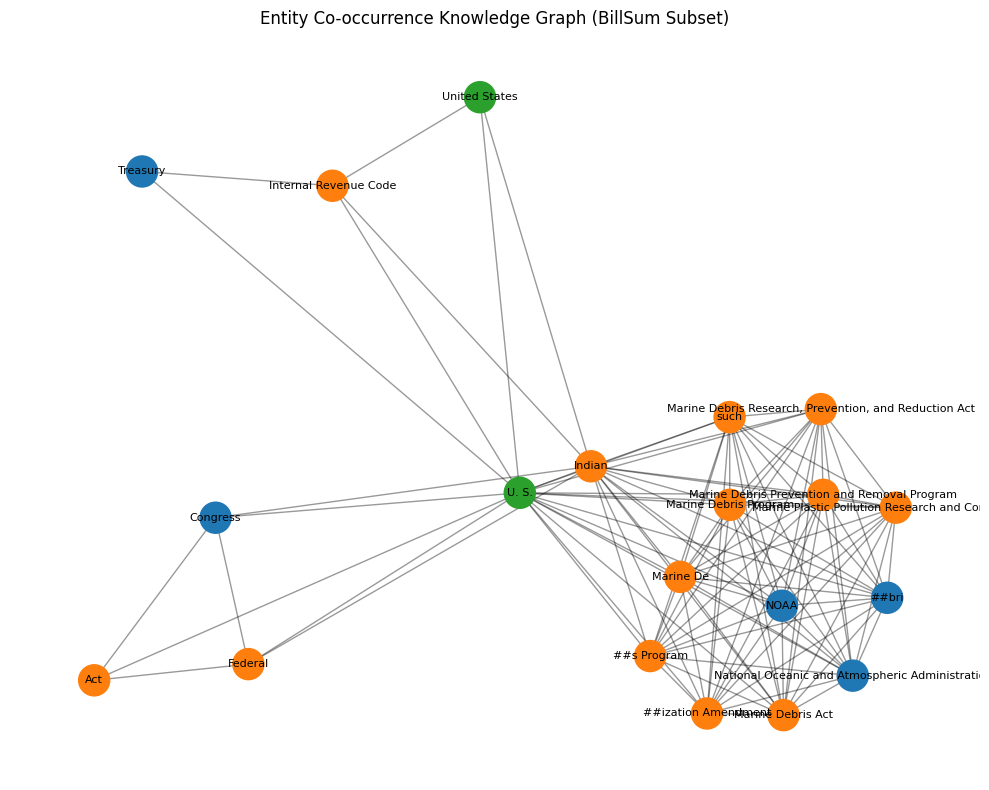

In [ ]:
# Take top 20 nodes by degree
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:20]
top_node_names = [n for n, d in top_nodes]

subG = G.subgraph(top_node_names)

plt.figure(figsize=(10, 8))

# Positions
pos = nx.spring_layout(subG, k=0.5, seed=42)

# Node colors by type
node_colors = []
for n in subG.nodes():
    t = subG.nodes[n].get("type", "MISC")
    if t == "ORG":
        node_colors.append("tab:blue")
    elif t == "LOC":
        node_colors.append("tab:green")
    else:  # MISC or other
        node_colors.append("tab:orange")

# Draw
nx.draw_networkx_nodes(subG, pos, node_color=node_colors, node_size=500)
nx.draw_networkx_edges(subG, pos, alpha=0.4)

nx.draw_networkx_labels(subG, pos, font_size=8)

plt.title("Entity Co-occurrence Knowledge Graph (BillSum Subset)")
plt.axis("off")
plt.tight_layout()
plt.show()


## Towards graph search and recommender systems
Instead of:
* “Find bills mentioning Marine Debris Act”

You can ask:
* “Find bills connected to Marine Debris Act and Marine Plastic Pollution Research”
* “Show entities two hops away from NOAA”

Think of how this can be used to serve content in social media! What would you do if you could see your social media graph...!